# GravWaveFormer - Notebook 2: Preprocessing Pipeline
**EGN 6217 Applied Deep Learning**

Converts raw HDF5 files into spectrograms (3×224×224) and waveforms (3×4096).


In [1]:
# Mount Drive & Setup
from google.colab import drive
drive.mount('/content/drive')
import os, numpy as np, h5py, torch, time
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

PROJECT_DIR  = '/content/drive/MyDrive/GravWaveFormer'
RAW_DATA_DIR = f'{PROJECT_DIR}/raw_data'
SPEC_DIR     = f'{PROJECT_DIR}/spectrograms'
WAVE_DIR     = f'{PROJECT_DIR}/waveforms'
RESULTS_DIR  = f'{PROJECT_DIR}/results'
os.makedirs(SPEC_DIR, exist_ok=True)
os.makedirs(WAVE_DIR, exist_ok=True)
print('Drive mounted')

Mounted at /content/drive
Drive mounted


In [2]:
# Install GWpy for Q-Transform
!pip install gwpy --quiet
print('GWpy installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 116.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.7 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.7 which is incompatible.
GWpy installed


In [3]:
# Preprocessing Functions
from scipy.signal import butter, filtfilt
from gwpy.timeseries import TimeSeries
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
normalise_2d = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def bandpass_filter(signal, lowcut=20.0, highcut=500.0, fs=2048.0, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)

def compute_qtransform(signal, sample_rate=2048, image_size=224):
    ts = TimeSeries(signal, sample_rate=sample_rate)
    try:
        qt = ts.q_transform(outseg=(0,2), qrange=(8,32), frange=(20,500), whiten=True)
        spec = np.log1p(np.abs(qt.value))
    except:
        from scipy.signal import spectrogram as sp
        _, _, Sxx = sp(signal, fs=sample_rate, nperseg=256, noverlap=192)
        spec = np.log1p(np.abs(Sxx))
    mn, mx = spec.min(), spec.max()
    if mx > mn:
        spec = ((spec - mn) / (mx - mn) * 255).astype(np.uint8)
    else:
        spec = np.zeros_like(spec, dtype=np.uint8)
    return np.array(Image.fromarray(spec).resize((image_size,image_size), Image.BILINEAR), dtype=np.float32)

def preprocess_sample(file_id):
    path = f'{RAW_DATA_DIR}/{file_id}.hdf5'
    try:
        with h5py.File(path, 'r') as f:
            dets = {d: f[f'{d}/SFTs'][:].flatten() for d in ['H1','L1','V1']}
        specs, waves = [], []
        for d in ['H1','L1','V1']:
            filt = bandpass_filter(dets[d])
            waves.append(filt)
            s = compute_qtransform(filt)
            mn, mx = s.min(), s.max()
            if mx > mn: s = (s - mn) / (mx - mn)
            specs.append(s)
        spec_t = normalise_2d(torch.tensor(np.stack(specs), dtype=torch.float32))
        wave_t = torch.tensor(np.stack(waves), dtype=torch.float32)
        for ch in range(3):
            m, s = wave_t[ch].mean(), wave_t[ch].std()
            if s > 0: wave_t[ch] = (wave_t[ch] - m) / s
        return spec_t, wave_t
    except Exception as e:
        print(f'  Error: {file_id} — {e}')
        return None, None

# Test
test_id = os.listdir(RAW_DATA_DIR)[0].replace('.hdf5','')
sp, wv = preprocess_sample(test_id)
print(f'Spectrogram: {sp.shape} | Waveform: {wv.shape}')
print('Preprocessing functions ready')

Spectrogram: torch.Size([3, 224, 224]) | Waveform: torch.Size([3, 4096])
Preprocessing functions ready


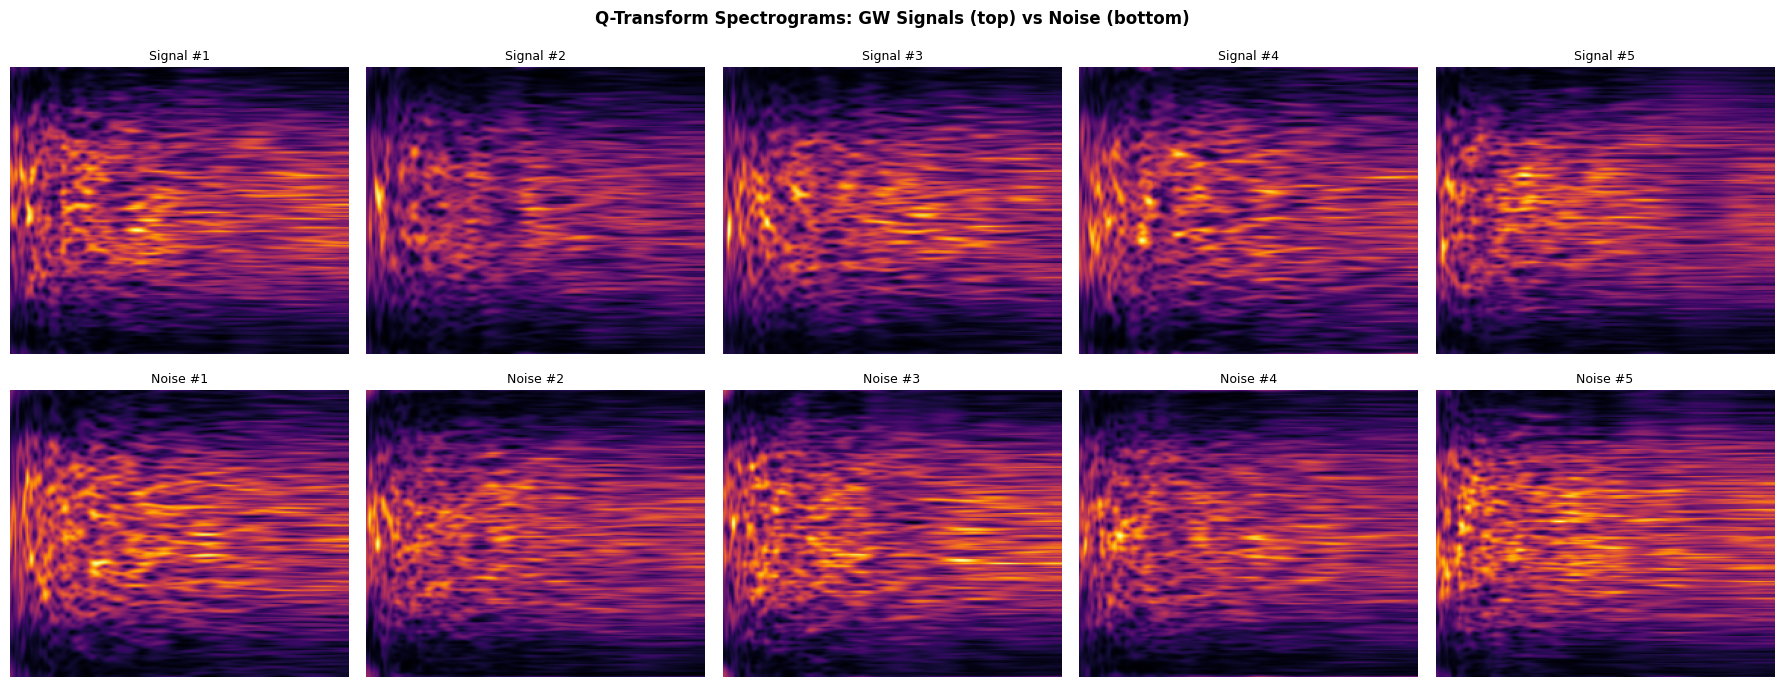

In [4]:
# Visualize Signal vs Noise Spectrograms
import pandas as pd
subset = pd.read_csv(f'{PROJECT_DIR}/subset_ids.csv')
signal_ids = subset[subset['target']==1]['id'].tolist()
noise_ids = subset[subset['target']==0]['id'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Q-Transform Spectrograms: GW Signals (top) vs Noise (bottom)', fontsize=12, fontweight='bold')
for col in range(5):
    for row, (ids, label) in enumerate([(signal_ids, 'Signal'), (noise_ids, 'Noise')]):
        spec, _ = preprocess_sample(ids[col])
        if spec is not None:
            axes[row,col].imshow(spec.mean(dim=0).numpy(), aspect='auto', origin='lower', cmap='inferno')
            axes[row,col].set_title(f'{label} #{col+1}', fontsize=9)
            axes[row,col].axis('off')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plot_signal_vs_noise_spectrograms.png', dpi=150)
plt.show()

In [5]:
# Cache All Samples — THE BIG CELL
# Processes all 5,000 samples. Takes ~2-3 hours.
# If Colab disconnects, re-run — skips already-cached files.

all_ids = subset['id'].tolist()
cached = set(f.replace('.pt','') for f in os.listdir(SPEC_DIR) if f.endswith('.pt'))
to_do = [i for i in all_ids if i not in cached]

print(f'Total: {len(all_ids):,} | Cached: {len(cached):,} | To process: {len(to_do):,}')

if to_do:
    start = time.time()
    ok = 0
    for i, fid in enumerate(to_do):
        sp, wv = preprocess_sample(fid)
        if sp is not None:
            torch.save(sp, f'{SPEC_DIR}/{fid}.pt')
            torch.save(wv, f'{WAVE_DIR}/{fid}.pt')
            ok += 1
        if (i+1) % 100 == 0:
            eta = (len(to_do)-i-1) / ((i+1)/(time.time()-start)) / 60
            print(f'  [{i+1:,}/{len(to_do):,}] OK:{ok} ETA:{eta:.0f}min')
    print(f'Done — {ok:,} processed in {(time.time()-start)/3600:.1f} hrs')
else:
    print('All cached!')

Total: 5,000 | Cached: 4,083 | To process: 917
  [100/917] OK:100 ETA:18min
  [200/917] OK:200 ETA:10min
  [300/917] OK:300 ETA:7min
  [400/917] OK:400 ETA:5min
  [500/917] OK:500 ETA:4min
  [600/917] OK:600 ETA:3min
  [700/917] OK:700 ETA:2min
  [800/917] OK:800 ETA:1min
  [900/917] OK:900 ETA:0min
Done — 917 processed in 0.1 hrs


In [6]:
# Create Train / Validation / Test Splits
from sklearn.model_selection import train_test_split

spec_ok = set(f.replace('.pt','') for f in os.listdir(SPEC_DIR) if f.endswith('.pt'))
wave_ok = set(f.replace('.pt','') for f in os.listdir(WAVE_DIR) if f.endswith('.pt'))
both = spec_ok & wave_ok
subset_ok = subset[subset['id'].isin(both)].reset_index(drop=True)

train_val, test_set = train_test_split(subset_ok, test_size=0.15, stratify=subset_ok['target'], random_state=42)
train_set, val_set = train_test_split(train_val, test_size=0.176, stratify=train_val['target'], random_state=42)

train_set.to_csv(f'{PROJECT_DIR}/split_train.csv', index=False)
val_set.to_csv(f'{PROJECT_DIR}/split_validation.csv', index=False)
test_set.to_csv(f'{PROJECT_DIR}/split_test.csv', index=False)

print(f'Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}')
print('NEXT: Notebook_03_Model.ipynb')

Train: 3,502 | Val: 748 | Test: 750
NEXT: Notebook_03_Model.ipynb
